In [22]:
# ============================================
# Synthetic CMD figure generator for
# F162M - F182M vs F162M
#
# Generates:
#   1) Isochrone grid
#   2) Interpolation schematic
#   3) Example CMD (resolved)
#   4) Resolved vs unresolved binaries
#   5) CMD grid vs cluster time
#   6) CMD grid vs epsilon_ff
#   7) Magnitude spread vs epsilon_ff
#   8) Magnitude spread vs age spread
#
# Assumes:
#   - SPISEA is installed
#   - nbody6tools.Reader is available
#   - nbody62spisea.converter is available
#   - your custom interpolator module is available
#   - the Nbody6 directory structure matches your old notebook
#
# Edit only the CONFIG section first.
# ============================================

import os
import math
import numpy as np
import matplotlib.pyplot as plt

from spisea import synthetic, evolution, atmospheres, reddening
from nbody6tools import Reader
from nbody62spisea import converter

import sys
sys.path.append('/scratch/wyz5rge/synthetic-hr/cmd_generator')
import interpolator


# ============================================================
# CONFIG
# ============================================================

OUTDIR = 'paper_figures_f162m_f182m'
os.makedirs(OUTDIR, exist_ok=True)

# --- SPISEA / photometry setup ---
AKs = 0.0
dist = 410
metallicity = 0
evo_model = evolution.Baraffe15()   # swap if needed
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawHosek18b()
iso_dir = 'isochrones/'             # change if needed

# Andersen-style CMD
filt_list = ['jwst,F162M', 'jwst,F182M']
filters = ['m_jwst_F162M', 'm_jwst_F182M']

# --- Nbody6 simulation roots ---
# Update these to match your directory structure.
# Keys are (sigma_cloud, epsilon_ff) and values are directories.
SIM_PATHS = {
    (1.0, 0.01): '/storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0/sfeff001_00/',
    (1.0, 0.03): '/storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0/sfeff003_00/',
    (1.0, 0.10): '/storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0/sfeff010_00/',
    (1.0, 0.30): '/storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0/sfeff030_00/',
    (1.0, 1.00): '/storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0/sfeff100_00/',
    (0.1, 0.01): '/storage/jfarias/Data/Orion/newbinaries/M3000sigma0.1/sfeff001_00/',
    (0.1, 0.03): '/storage/jfarias/Data/Orion/newbinaries/M3000sigma0.1/sfeff003_00/',
    (0.1, 0.10): '/storage/jfarias/Data/Orion/newbinaries/M3000sigma0.1/sfeff010_00/',
    (0.1, 0.30): '/storage/jfarias/Data/Orion/newbinaries/M3000sigma0.1/sfeff030_00/',
    (0.1, 1.00): '/storage/jfarias/Data/Orion/newbinaries/M3000sigma0.1/sfeff100_00/',
}

# --- Example selections for paper figures ---
EXAMPLE_SIGMA = 1.0
EXAMPLE_EPSFF = 0.03
EXAMPLE_TIME = 1.5

# TIME_GRID_FOR_CMD = [1.0, 5.0, 10.0]
TIME_GRID_FOR_CMD = [1.0, 2.0, 5.0]
TIME_GRID_FOR_AGE_EVOLUTION_FIG = [1.0, 2.0, 5.0]
EPSFF_GRID_FOR_CMD = [0.01, 0.03, 0.10, 0.30, 1.00]

# Age grid generation for SPISEA interpolation
AGE_INCREMENT_YR = 0.5e6
MIN_GRID_AGE_YR = 0.5e6
MAX_GRID_AGE_YR = 20e6

# Magnitude spread metric setup
SPREAD_COLOR_BINS = 8
SPREAD_MIN_STARS_PER_BIN = 5

# Manual CMD box for spread metric
# You may need to tune these after seeing the new F162M-F182M geometry.
SPREAD_BOX = {
    'x_min': 0.0,
    'x_max': 1.2,
    'y_min': 9.5,
    'y_max': 16.5,
}

# Plot styling
POINT_SIZE = 2
ISO_LW = 1.2
DPI = 220


# ============================================================
# HELPERS
# ============================================================

def cmd_color(mag1, mag2):
    return mag1 - mag2

def flux_from_mag(mag, zp_flux):
    return 10.0 ** (-mag / 2.5) * zp_flux

def mag_from_flux(flux, zp_flux):
    return -2.5 * np.log10(flux / zp_flux)

def get_sim_path(sigma_cloud, epsff):
    key = (sigma_cloud, epsff)
    if key not in SIM_PATHS:
        raise KeyError(f'No path configured for sigma={sigma_cloud}, epsff={epsff}')
    return SIM_PATHS[key]

def read_cluster_table(path, snapshot_time_myr):
    snapshot = Reader.read_snapshot(path, time=snapshot_time_myr)
    snapshot.to_physical()
    cluster_table = converter.to_spicea_table(snapshot)
    return cluster_table

def get_cluster_arrays(cluster_table):
    masses = np.array(cluster_table['mass'], dtype=float)
    ages_myr = np.array(cluster_table['age'], dtype=float)
    ages_yr = ages_myr * 1e6
    log_ages = np.log10(ages_yr)
    return masses, ages_myr, ages_yr, log_ages

def find_first_binary(cluster_table):
    for i in range(len(cluster_table)):
        if cluster_table['isMultiple'][i] == 1.0:
            return i
    return len(cluster_table)

def get_companion_masses(cluster_table, first_binary):
    comp_masses = []
    for i in range(first_binary, len(cluster_table)):
        if cluster_table['isMultiple'][i] == 1.0 and len(cluster_table['compMass'][i]) > 0:
            comp_masses.append(cluster_table['compMass'][i][0])
    return np.array(comp_masses, dtype=float)

def build_age_grid_from_cluster(ages_yr, increment_yr=AGE_INCREMENT_YR):
    start = max(MIN_GRID_AGE_YR, (np.min(ages_yr) // increment_yr) * increment_yr)
    end = min(MAX_GRID_AGE_YR, (np.max(ages_yr) // increment_yr) * increment_yr + 2 * increment_yr)
    level_age_arr = np.arange(start, end, increment_yr)
    log_age_arr = np.log10(level_age_arr)
    return level_age_arr, log_age_arr

def build_manual_age_grid():
    level_age_arr = np.arange(MIN_GRID_AGE_YR, MAX_GRID_AGE_YR + AGE_INCREMENT_YR, AGE_INCREMENT_YR)
    log_age_arr = np.log10(level_age_arr)
    return level_age_arr, log_age_arr

def generate_isochrones(log_age_arr):
    instances = np.empty(len(log_age_arr), dtype=object)
    for i, log_age in enumerate(log_age_arr):
        my_iso = synthetic.IsochronePhot(
            log_age,
            AKs,
            dist,
            metallicity=metallicity,
            evo_model=evo_model,
            atm_func=atm_func,
            red_law=red_law,
            filters=filt_list,
            iso_dir=iso_dir
        )
        instances[i] = my_iso
    return instances

def interpolate_stars(cluster_table, masses, ages_myr, instances, log_age_arr):
    stars = np.empty(len(cluster_table), dtype=object)
    for i in range(len(stars)):
        stars[i] = interpolator.interpolate(ages_myr[i], masses[i], instances, log_age_arr, filters)
    return stars

def interpolate_companions(cluster_table, first_binary, comp_masses, ages_myr, instances, log_age_arr, stars):
    companions = np.empty(len(comp_masses), dtype=object)
    for i in range(len(comp_masses)):
        if stars[first_binary + i] is None:
            continue
        companions[i] = interpolator.interpolate(
            ages_myr[first_binary + i],
            comp_masses[i],
            instances,
            log_age_arr,
            filters
        )
    return companions

def unresolved_binary_mags(stars, companions, first_binary):

    unresolved = np.empty(len(companions), dtype=object)

    for i in range(len(companions)):

        if stars[first_binary + i] is None or companions[i] is None:
            continue

        m1_primary = stars[first_binary + i][3]
        m2_primary = stars[first_binary + i][4]

        m1_comp = companions[i][3]
        m2_comp = companions[i][4]

        # combine fluxes directly in magnitude space
        mag1 = -2.5 * np.log10(
            10 ** (-0.4 * m1_primary) + 10 ** (-0.4 * m1_comp)
        )

        mag2 = -2.5 * np.log10(
            10 ** (-0.4 * m2_primary) + 10 ** (-0.4 * m2_comp)
        )

        unresolved[i] = [mag1, mag2]

    return unresolved

def extract_cmd_arrays_from_stars(stars):
    x, y = [], []
    for s in stars:
        if s is None:
            continue
        mag1 = s[3]
        mag2 = s[4]
        x.append(mag1 - mag2)
        y.append(mag1)
    return np.array(x), np.array(y)

def extract_cmd_arrays_for_resolved(cluster_table, stars, companions, first_binary):
    xs, ys = [], []

    # singles + primaries
    for i in range(len(stars)):
        if stars[i] is None:
            continue
        mag1 = stars[i][3]
        mag2 = stars[i][4]
        xs.append(mag1 - mag2)
        ys.append(mag1)

    # companions as separate sources
    for c in companions:
        if c is None:
            continue
        mag1 = c[3]
        mag2 = c[4]
        xs.append(mag1 - mag2)
        ys.append(mag1)

    return np.array(xs), np.array(ys)

def extract_cmd_arrays_primary_only(cluster_table, stars, first_binary):
    xs, ys = [], []

    # singles + binary primaries only
    for i in range(len(stars)):
        if stars[i] is None:
            continue
        mag1 = stars[i][3]
        mag2 = stars[i][4]
        xs.append(mag1 - mag2)
        ys.append(mag1)

    return np.array(xs), np.array(ys)


def extract_cmd_arrays_for_unresolved_split(cluster_table, stars, unresolved, first_binary):
    # singles / primaries that remain black
    x_single, y_single = [], []

    # unresolved-combined binaries that will be green
    x_unres_bin, y_unres_bin = [], []

    # single stars before first binary
    for i in range(first_binary):
        if stars[i] is None:
            continue
        mag1 = stars[i][3]
        mag2 = stars[i][4]
        x_single.append(mag1 - mag2)
        y_single.append(mag1)

    # unresolved binaries
    for ub in unresolved:
        if ub is None:
            continue
        mag1, mag2 = ub
        x_unres_bin.append(mag1 - mag2)
        y_unres_bin.append(mag1)

    return (
        np.array(x_single), np.array(y_single),
        np.array(x_unres_bin), np.array(y_unres_bin)
    )

def plot_isochrones(ax, instances, ages_myr=None, alpha=0.9, cmap='coolwarm', lw=None):
    if lw is None:
        lw = ISO_LW

    n = len(instances)
    cmap_obj = plt.cm.get_cmap(cmap, n)

    for i, iso in enumerate(instances):
        x = iso.points[filters[0]] - iso.points[filters[1]]
        y = iso.points[filters[0]]
        ax.plot(x, y, color=cmap_obj(i), lw=lw, alpha=alpha)

    sm = plt.cm.ScalarMappable(
        cmap=cmap_obj,
        norm=plt.Normalize(
            vmin=ages_myr[0] if ages_myr is not None else 0,
            vmax=ages_myr[-1] if ages_myr is not None else n - 1
        )
    )
    sm.set_array([])
    return sm

def set_cmd_axes(ax, title=None, xlim=None, ylim=None):
    ax.set_xlabel('F162M - F182M')
    ax.set_ylabel('F162M')
    ax.invert_yaxis()
    if title is not None:
        ax.set_title(title)
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

def get_cmd_limits_from_arrays(arrays_x, arrays_y, pad_x=0.03, pad_y=0.3):
    x_all = np.concatenate([a for a in arrays_x if len(a) > 0])
    y_all = np.concatenate([a for a in arrays_y if len(a) > 0])
    xmin, xmax = np.nanmin(x_all), np.nanmax(x_all)
    ymin, ymax = np.nanmin(y_all), np.nanmax(y_all)
    return (xmin - pad_x, xmax + pad_x), (ymax + pad_y, ymin - pad_y)

def compute_age_spread_myr(ages_myr):
    return np.percentile(ages_myr, 95) - np.percentile(ages_myr, 5)

def compute_mag_spread_metric(x, y, box=SPREAD_BOX, nbins=SPREAD_COLOR_BINS, min_stars=SPREAD_MIN_STARS_PER_BIN):
    mask = (
        (x >= box['x_min']) &
        (x <= box['x_max']) &
        (y >= box['y_min']) &
        (y <= box['y_max'])
    )

    x_sel = x[mask]
    y_sel = y[mask]

    if len(x_sel) < min_stars:
        return np.nan

    bins = np.linspace(box['x_min'], box['x_max'], nbins + 1)
    sigmas = []

    for i in range(nbins):
        in_bin = (x_sel >= bins[i]) & (x_sel < bins[i + 1])
        if np.sum(in_bin) >= min_stars:
            sigmas.append(np.std(y_sel[in_bin]))

    if len(sigmas) == 0:
        return np.nan
    return float(np.mean(sigmas))

def prepare_snapshot(sigma_cloud, epsff, snapshot_time_myr, use_cluster_age_grid=True):
    path = get_sim_path(sigma_cloud, epsff)
    cluster_table = read_cluster_table(path, snapshot_time_myr)
    masses, ages_myr, ages_yr, log_ages = get_cluster_arrays(cluster_table)

    if use_cluster_age_grid:
        level_age_arr, log_age_arr = build_age_grid_from_cluster(ages_yr)
    else:
        level_age_arr, log_age_arr = build_manual_age_grid()

    instances = generate_isochrones(log_age_arr)

    first_binary = find_first_binary(cluster_table)
    comp_masses = get_companion_masses(cluster_table, first_binary)

    stars = interpolate_stars(cluster_table, masses, ages_myr, instances, log_age_arr)
    companions = interpolate_companions(
        cluster_table, first_binary, comp_masses, ages_myr, instances, log_age_arr, stars
    )
    unresolved = unresolved_binary_mags(stars, companions, first_binary)

    x_res, y_res = extract_cmd_arrays_for_resolved(cluster_table, stars, companions, first_binary)
    x_unres, y_unres = extract_cmd_arrays_for_unresolved(cluster_table, stars, unresolved, first_binary)
    x_primary, y_primary = extract_cmd_arrays_primary_only(cluster_table, stars, first_binary)

    x_single_unres, y_single_unres, x_bin_unres, y_bin_unres = extract_cmd_arrays_for_unresolved_split(
        cluster_table, stars, unresolved, first_binary
    )

    return {
        'cluster_table': cluster_table,
        'masses': masses,
        'ages_myr': ages_myr,
        'ages_yr': ages_yr,
        'log_ages': log_ages,
        'level_age_arr': level_age_arr,
        'log_age_arr': log_age_arr,
        'instances': instances,
        'first_binary': first_binary,
        'comp_masses': comp_masses,
        'stars': stars,
        'companions': companions,
        'unresolved': unresolved,
        'x_res': x_res,
        'y_res': y_res,
        'x_unres': x_unres,
        'y_unres': y_unres,
        'x_primary': x_primary,
        'y_primary': y_primary,
        'x_single_unres': x_single_unres,
        'y_single_unres': y_single_unres,
        'x_bin_unres': x_bin_unres,
        'y_bin_unres': y_bin_unres,
        'age_spread_myr': compute_age_spread_myr(ages_myr),
        'mag_spread_res': compute_mag_spread_metric(x_res, y_res),
        'mag_spread_unres': compute_mag_spread_metric(x_unres, y_unres),
    }

# ============================================================
# FIGURE 1: Isochrone grid
# ============================================================

def make_figure_isochrone_grid():
    level_age_arr, log_age_arr = build_manual_age_grid()
    instances = generate_isochrones(log_age_arr)
    ages_myr = level_age_arr / 1e6

    fig, ax = plt.subplots(figsize=(6.2, 8.0))
    sm = plot_isochrones(ax, instances, ages_myr=ages_myr, alpha=0.95, cmap='coolwarm')

    set_cmd_axes(ax, title='Isochrone Grid: F162M - F182M vs F162M')
    ax.grid(alpha=0.2)

    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label('Isochrone Age (Myr)')

    fig.tight_layout()
    fig.savefig(os.path.join(OUTDIR, 'fig_isochrone_grid_f162m_f182m.png'), dpi=DPI, bbox_inches='tight')
    plt.show()


# ============================================================
# FIGURE 2: Interpolation schematic
# ============================================================

def make_figure_interpolation_schematic():
    # Force exactly 1 Myr and 2 Myr to widen the gap
    level_age_arr = np.array([1.0e6, 2.0e6])
    log_age_arr = np.log10(level_age_arr)
    instances = generate_isochrones(log_age_arr)

    iso1 = instances[0]   # 1 Myr
    iso2 = instances[1]   # 2 Myr

    target_mass = 0.26
    target_age_myr = 1.5

    m1_arr = np.array(iso1.points['mass'])
    m2_arr = np.array(iso2.points['mass'])

    # find bracketing mass indices for target mass on each isochrone
    def get_bracketing_indices(mass_arr, target_mass):
        idx_hi = np.searchsorted(mass_arr, target_mass)
        idx_hi = min(max(idx_hi, 1), len(mass_arr) - 1)
        idx_lo = idx_hi - 1
        return idx_lo, idx_hi

    i1_lo, i1_hi = get_bracketing_indices(m1_arr, target_mass)
    i2_lo, i2_hi = get_bracketing_indices(m2_arr, target_mass)

    # actual isochrone points that bracket the target mass
    p1_lo = np.array([
        iso1.points[filters[0]][i1_lo] - iso1.points[filters[1]][i1_lo],
        iso1.points[filters[0]][i1_lo]
    ])
    p1_hi = np.array([
        iso1.points[filters[0]][i1_hi] - iso1.points[filters[1]][i1_hi],
        iso1.points[filters[0]][i1_hi]
    ])

    p2_lo = np.array([
        iso2.points[filters[0]][i2_lo] - iso2.points[filters[1]][i2_lo],
        iso2.points[filters[0]][i2_lo]
    ])
    p2_hi = np.array([
        iso2.points[filters[0]][i2_hi] - iso2.points[filters[1]][i2_hi],
        iso2.points[filters[0]][i2_hi]
    ])

    # mass interpolation fractions
    f1 = (target_mass - m1_arr[i1_lo]) / (m1_arr[i1_hi] - m1_arr[i1_lo] + 1e-12)
    f2 = (target_mass - m2_arr[i2_lo]) / (m2_arr[i2_hi] - m2_arr[i2_lo] + 1e-12)

    # interpolated mass points on each isochrone
    p1_mass = p1_lo + f1 * (p1_hi - p1_lo)
    p2_mass = p2_lo + f2 * (p2_hi - p2_lo)

    # age interpolation between those mass-interpolated points
    age1_myr = 1.0
    age2_myr = 2.0
    fa = (target_age_myr - age1_myr) / (age2_myr - age1_myr)
    p_final = p1_mass + fa * (p2_mass - p1_mass)

    fig, ax = plt.subplots(figsize=(6.2, 8.0))

    # plot full isochrones
    ax.plot(iso1.points[filters[0]] - iso1.points[filters[1]],
            iso1.points[filters[0]],
            color='royalblue', lw=2, label='1 Myr Isochrone')

    ax.plot(iso2.points[filters[0]] - iso2.points[filters[1]],
            iso2.points[filters[0]],
            color='firebrick', lw=2, label='2 Myr Isochrone')

    # show actual discrete isochrone points used for the mass interpolation
    ax.scatter([p1_lo[0], p1_hi[0]], [p1_lo[1], p1_hi[1]],
               color='royalblue', marker='s', s=45, zorder=5, label='1 Myr bracketing points')
    ax.scatter([p2_lo[0], p2_hi[0]], [p2_lo[1], p2_hi[1]],
               color='firebrick', marker='s', s=45, zorder=5, label='2 Myr bracketing points')

    # connect bracketing points along each isochrone
    ax.plot([p1_lo[0], p1_hi[0]], [p1_lo[1], p1_hi[1]],
            color='royalblue', ls='--', lw=1.4)
    ax.plot([p2_lo[0], p2_hi[0]], [p2_lo[1], p2_hi[1]],
            color='firebrick', ls='--', lw=1.4)

    # mass-interpolated points
    ax.scatter(p1_mass[0], p1_mass[1], color='royalblue', s=100, marker='*', zorder=6, label='Mass-interpolated points')
    ax.scatter(p2_mass[0], p2_mass[1], color='firebrick', s=100, marker='*', zorder=6)

    # age interpolation line
    ax.plot([p1_mass[0], p2_mass[0]], [p1_mass[1], p2_mass[1]],
            color='green', ls='--', lw=1.6, label='Age interpolation')

    # final point
    ax.scatter(p_final[0], p_final[1], color='green', s=110, marker='o', zorder=7,
               label=fr'Final star ($M={target_mass:.1f}\,M_\odot,\ t={target_age_myr:.1f}$ Myr)')

    set_cmd_axes(ax, title='Bilinear Interpolation Schematic')
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8, loc='best')

    fig.tight_layout()
    fig.savefig(os.path.join(OUTDIR, 'fig_interpolation_schematic_f162m_f182m.png'), dpi=DPI, bbox_inches='tight')
    plt.show()


# ============================================================
# FIGURE 3: Example synthetic CMD (resolved)
# ============================================================

def make_figure_example_cmd():
    data = prepare_snapshot(EXAMPLE_SIGMA, EXAMPLE_EPSFF, EXAMPLE_TIME)

    fig, ax = plt.subplots(figsize=(6.0, 8.0))
    plot_isochrones(ax, data['instances'], ages_myr=data['level_age_arr'] / 1e6, alpha=0.7)
    ax.scatter(data['x_primary'], data['y_primary'], s=POINT_SIZE, c='k', alpha=0.7)

    set_cmd_axes(
        ax,
        title=f'Example CMD: sigma={EXAMPLE_SIGMA}, epsff={EXAMPLE_EPSFF}, t={EXAMPLE_TIME} Myr'
    )
    ax.grid(alpha=0.2)

    fig.tight_layout()
    fig.savefig(os.path.join(OUTDIR, 'fig_cmd_example_f162m_f182m.png'), dpi=DPI, bbox_inches='tight')
    plt.show()


# ============================================================
# FIGURE 4: Resolved vs unresolved binaries
# ============================================================

def make_figure_binaries_comparison():
    data = prepare_snapshot(EXAMPLE_SIGMA, EXAMPLE_EPSFF, EXAMPLE_TIME)

    xlim, ylim = get_cmd_limits_from_arrays(
        [data['x_res'], data['x_single_unres'], data['x_bin_unres']],
        [data['y_res'], data['y_single_unres'], data['y_bin_unres']]
    )

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 8.0), sharex=True, sharey=True)

    # Left: resolved binaries
    plot_isochrones(axes[0], data['instances'], ages_myr=data['level_age_arr'] / 1e6, alpha=0.6)

    # singles + primaries + companions all black in resolved case
    axes[0].scatter(data['x_res'], data['y_res'], s=POINT_SIZE, c='k', alpha=0.65)

    set_cmd_axes(axes[0], title='Resolved Binaries', xlim=xlim, ylim=ylim)
    axes[0].grid(alpha=0.2)

    # Right: unresolved binaries with color split
    plot_isochrones(axes[1], data['instances'], ages_myr=data['level_age_arr'] / 1e6, alpha=0.6)

    # single stars black
    axes[1].scatter(data['x_single_unres'], data['y_single_unres'],
                    s=POINT_SIZE, c='k', alpha=0.65, label='Single stars')

    # unresolved binaries green
    axes[1].scatter(data['x_bin_unres'], data['y_bin_unres'],
                    s=POINT_SIZE, c='green', alpha=0.75, label='Unresolved binaries')

    set_cmd_axes(axes[1], title='Unresolved Binaries', xlim=xlim, ylim=ylim)
    axes[1].grid(alpha=0.2)
    axes[1].legend(fontsize=9, loc='best')

    fig.tight_layout()
    fig.savefig(os.path.join(OUTDIR, 'fig_cmd_binaries_f162m_f182m.png'), dpi=DPI, bbox_inches='tight')
    plt.show()


# ============================================================
# FIGURE 5: CMD grid vs cluster time
# ============================================================

def make_figure_cmd_age_grid():
    results = []
    for t in TIME_GRID_FOR_CMD:
        results.append(prepare_snapshot(EXAMPLE_SIGMA, EXAMPLE_EPSFF, t))

    xlim, ylim = get_cmd_limits_from_arrays(
        [r['x_res'] for r in results],
        [r['y_res'] for r in results]
    )

    fig, axes = plt.subplots(1, len(TIME_GRID_FOR_CMD), figsize=(5.2 * len(TIME_GRID_FOR_CMD), 8.0), sharex=True, sharey=True)
    if len(TIME_GRID_FOR_CMD) == 1:
        axes = [axes]

    for ax, t, r in zip(axes, TIME_GRID_FOR_CMD, results):
        plot_isochrones(ax, r['instances'], alpha=0.6)
        ax.scatter(r['x_res'], r['y_res'], s=POINT_SIZE, c='k', alpha=0.65)
        set_cmd_axes(ax, title=f't = {t:.1f} Myr', xlim=xlim, ylim=ylim)
        ax.grid(alpha=0.2)

    fig.suptitle(f'CMD Evolution with Cluster Time\nsigma={EXAMPLE_SIGMA}, epsff={EXAMPLE_EPSFF}', y=1.02)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(os.path.join(OUTDIR, 'fig_cmd_age_grid_f162m_f182m.png'), dpi=DPI, bbox_inches='tight')
    plt.show()


# ============================================================
# FIGURE 6: CMD grid vs epsilon_ff
# ============================================================

def make_figure_cmd_epsff_grid():
    results = []
    for eps in EPSFF_GRID_FOR_CMD:
        results.append(prepare_snapshot(EXAMPLE_SIGMA, eps, EXAMPLE_TIME))

    xlim, ylim = get_cmd_limits_from_arrays(
        [r['x_res'] for r in results],
        [r['y_res'] for r in results]
    )

    n = len(EPSFF_GRID_FOR_CMD)
    ncols = min(3, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5.3 * ncols, 7.0 * nrows), sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)

    for ax, eps, r in zip(axes, EPSFF_GRID_FOR_CMD, results):
        plot_isochrones(ax, r['instances'], alpha=0.55)
        ax.scatter(r['x_res'], r['y_res'], s=POINT_SIZE, c='k', alpha=0.65)
        set_cmd_axes(ax, title=f'epsff = {eps:.2f}', xlim=xlim, ylim=ylim)
        ax.grid(alpha=0.2)

    for ax in axes[len(results):]:
        ax.axis('off')

    fig.suptitle(f'CMD Morphology vs Freefall Efficiency\nsigma={EXAMPLE_SIGMA}, t={EXAMPLE_TIME} Myr', y=1.01)
    fig.tight_layout()
    fig.savefig(os.path.join(OUTDIR, 'fig_cmd_epsff_grid_f162m_f182m.png'), dpi=DPI, bbox_inches='tight')
    plt.show()


# ============================================================
# FIGURE 7: Magnitude spread vs epsilon_ff
# ============================================================

def make_figure_magspread_vs_epsff():
    sigma_values = sorted(set([k[0] for k in SIM_PATHS.keys()]))
    eps_values = sorted(set([k[1] for k in SIM_PATHS.keys()]))

    fig, ax = plt.subplots(figsize=(7.0, 5.5))

    for sigma in sigma_values:
        y_res = []
        y_unres = []
        xs = []

        for eps in eps_values:
            if (sigma, eps) not in SIM_PATHS:
                continue
            r = prepare_snapshot(sigma, eps, EXAMPLE_TIME)
            xs.append(eps)
            y_res.append(r['mag_spread_res'])
            y_unres.append(r['mag_spread_unres'])

        ax.plot(xs, y_res, marker='o', label=fr'$\Sigma_{{cloud}}={sigma}$ resolved')
        ax.plot(xs, y_unres, marker='^', ls='--', label=fr'$\Sigma_{{cloud}}={sigma}$ unresolved')

    ax.set_xscale('log')
    ax.set_xlabel(r'$\epsilon_{\rm ff}$')
    ax.set_ylabel(r'Average magnitude spread, $\Delta m$')
    ax.set_title(f'Magnitude Spread vs Freefall Efficiency (t = {EXAMPLE_TIME} Myr)')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

    fig.tight_layout()
    fig.savefig(os.path.join(OUTDIR, 'fig_magspread_vs_epsff_f162m_f182m.png'), dpi=DPI, bbox_inches='tight')
    plt.show()


# ============================================================
# FIGURE 8: Magnitude spread vs age spread
# ============================================================

def make_figure_magspread_vs_agespread():
    sigma_values = sorted(set([k[0] for k in SIM_PATHS.keys()]))
    eps_values = sorted(set([k[1] for k in SIM_PATHS.keys()]))

    fig, ax = plt.subplots(figsize=(7.0, 5.5))

    for sigma in sigma_values:
        for eps in eps_values:
            if (sigma, eps) not in SIM_PATHS:
                continue

            age_spreads = []
            mag_spreads = []

            for t in TIME_GRID_FOR_CMD:
                r = prepare_snapshot(sigma, eps, t)
                age_spreads.append(r['age_spread_myr'])
                mag_spreads.append(r['mag_spread_res'])

            ax.plot(age_spreads, mag_spreads, marker='o', label=fr'$\Sigma={sigma}, \epsilon_{{ff}}={eps}$')

    ax.set_xscale('log')
    ax.set_xlabel('Age spread (Myr)')
    ax.set_ylabel(r'Average magnitude spread, $\Delta m$')
    ax.set_title('Magnitude Spread vs Age Spread')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7, ncol=2)

    fig.tight_layout()
    fig.savefig(os.path.join(OUTDIR, 'fig_magspread_vs_agespread_f162m_f182m.png'), dpi=DPI, bbox_inches='tight')
    plt.show()



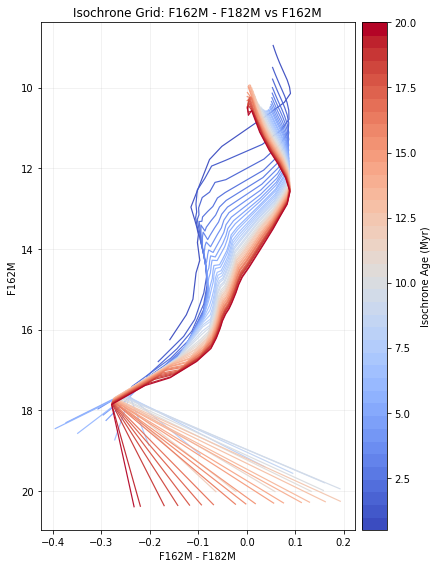

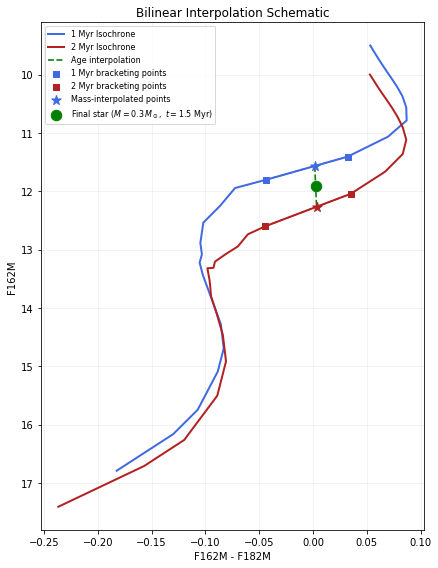

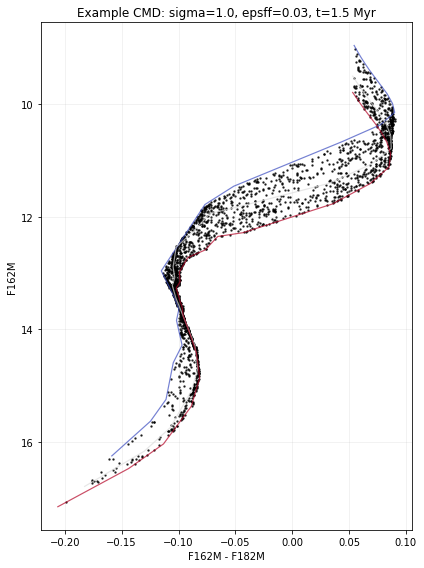

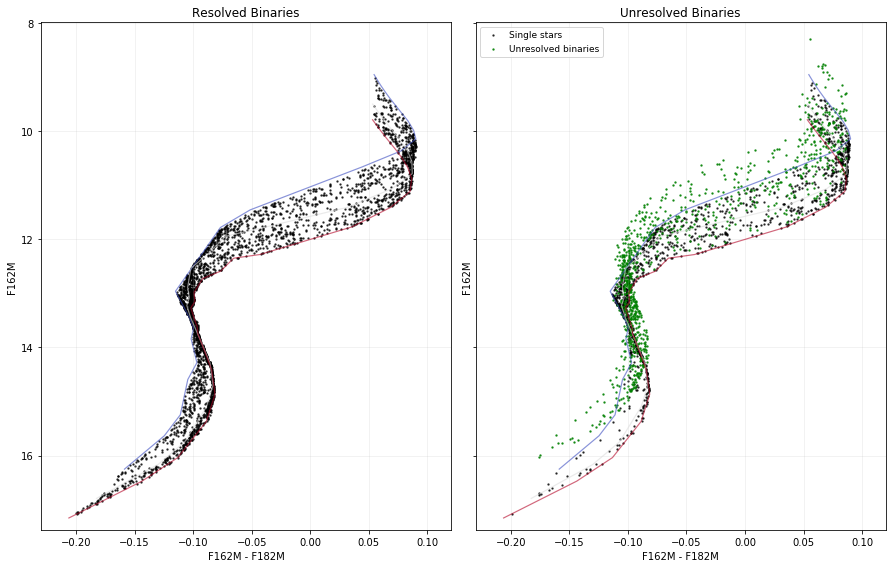

/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:94: RuntimeWarning: divide by zero encountered in double_scalars
  w1 = (np.power(10, age_arr[a2]) / 1000000 - age) / (np.power(10, age_arr[a2]) / 1000000 - np.power(10, age_arr[a1]) / 1000000)
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:99: RuntimeWarning: invalid value encountered in double_scalars
  s_lum = w1 * s1[1] + w2 * s2[1]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:100: RuntimeWarning: invalid value encountered in double_scalars
  s_teff = w1 * s1[2] + w2 * s2[2]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:101: RuntimeWarning: invalid value encountered in double_scalars
  s_logg = w1 * s1[3] + w2 * s2[3]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:102: RuntimeWarning: invalid value encountered in double_scalars
  s_filt1 = w1 * s1[4] + w2 * s2[4]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:103: RuntimeWarning: invalid value encountered 

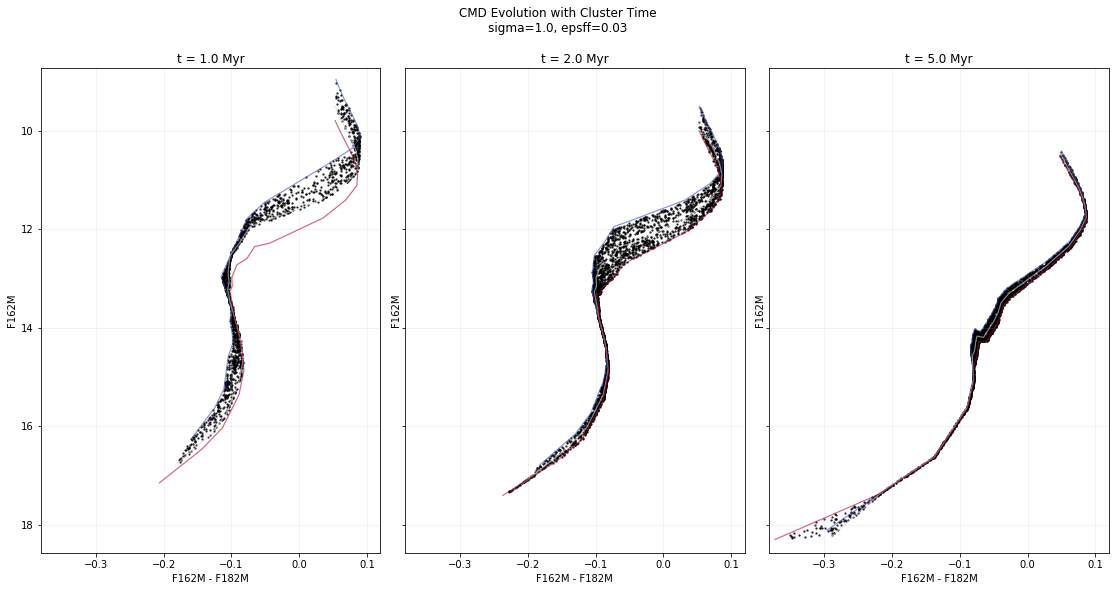

Finished. Figures saved to: paper_figures_f162m_f182m


In [23]:
# ============================================================
# RUN ALL
# ============================================================

make_figure_isochrone_grid()
make_figure_interpolation_schematic()
make_figure_example_cmd()
make_figure_binaries_comparison()
make_figure_cmd_age_grid()
'''
make_figure_cmd_epsff_grid()
make_figure_magspread_vs_epsff()
make_figure_magspread_vs_agespread()
'''

print(f'Finished. Figures saved to: {OUTDIR}')